# **DATA AND BUSINESS PROBLEM UNDERSTANDING**

This notebook focuses on the initial data understanding phase of the KKBox churn prediction project.

The goal is to explore the structure, quality, and main characteristics of each dataset in order to identify potential issues and understand the data before preprocessing.

No transformations are applied at this stage.


### 1. **UNDERSTANDING DATA**

#### 1.1 Imports

In [2]:
# import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### 1.2. Data Loading

##### 1.2.1. Train (Initial EDA)

In [3]:
# 1. Load train_v2.csv dataset
train = pd.read_csv("C:/Users/pauli/OneDrive/Documentos/GitHub/Customer-Churn-Intelligence-System/data/raw/train_v2.csv")

In [4]:
# 2. Dataset Structure
print("Dataset info:")
train.info()
print(f"\nDataset shape: {train.shape}")
print(f"\nDataset columns: {list(train.columns)}")
print(f"\nDataset datatypes:\n{train.dtypes}")

# number of unique values in each column
print("\nNumber of unique values in each column:")
print(train.nunique())

# print first few rows of the dataset
train.head()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970960 entries, 0 to 970959
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   msno      970960 non-null  object
 1   is_churn  970960 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 14.8+ MB

Dataset shape: (970960, 2)

Dataset columns: ['msno', 'is_churn']

Dataset datatypes:
msno        object
is_churn     int64
dtype: object

Number of unique values in each column:
msno        970960
is_churn         2
dtype: int64


,msno,is_churn
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1


In [5]:
# 3. Data Quality Assessment

# check for missing values
print("\nNumber of missing values in each column:")
print(train.isnull().sum())

# check percentage of missing values in each column
print(f"\nPercentage of missing values in each column:")
print((train.isnull().sum() / len(train) * 100).round(2
))

# check for duplicates in user id
print(f"\nDuplicated values in msno column: {train['msno'].duplicated().sum()}")



Number of missing values in each column:
msno        0
is_churn    0
dtype: int64

Percentage of missing values in each column:
msno        0.0
is_churn    0.0
dtype: float64

Duplicated values in msno column: 0


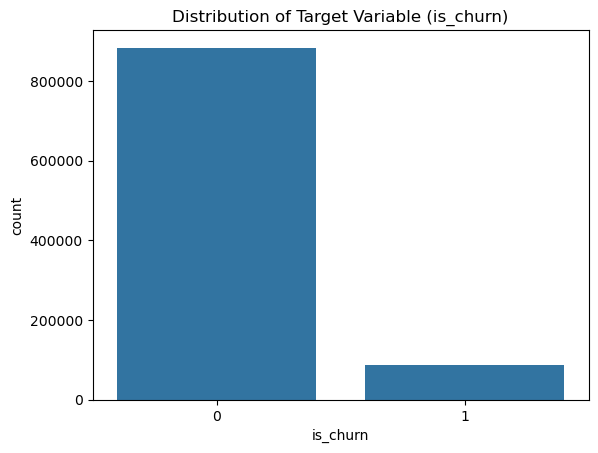


The target variable is imbalanced.
Percentage of churned customers: 8.99%


In [6]:
# 4. Target Variable Distribution
sns.countplot(x='is_churn', data=train)
plt.title("Distribution of Target Variable (is_churn)")
plt.show()

if train['is_churn'].value_counts().min() / train['is_churn'].value_counts().max() < 0.5:
    print("\nThe target variable is imbalanced.")
else:
    print("\nThe target variable is balanced.")

# print percentage of churned customers 
churn_percentage = train['is_churn'].mean() * 100
print(f"Percentage of churned customers: {churn_percentage:.2f}%")

##### 1.2.2. Members (Initial EDA)

In [7]:
# 1. Load members_v3.csv dataset
members = pd.read_csv("C:/Users/pauli/OneDrive/Documentos/GitHub/Customer-Churn-Intelligence-System/data/raw/members_v3.csv")   


In [8]:

# 2. Dataset Structure
print("Dataset info:")
members.info()

print(f"\nDataset shape: {members.shape}")

print(f"\nDataset columns: {list(members.columns)}")

print(f"\nDataset datatypes:\n{members.dtypes}")

# number of unique values in each column
print("\nNumber of unique values in each column:")
print(members.nunique())

# identify numerical and categorical columns
numerical_cols = members.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = members.select_dtypes(include=['object']).columns

print(f"\nNumerical columns: {list(numerical_cols)}")
print(f"\nCategorical columns: {list(categorical_cols)}")

# print first few rows of the dataset
pd.set_option('display.max_columns', None)
members.head()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6769473 entries, 0 to 6769472
Data columns (total 6 columns):
 #   Column                  Dtype 
---  ------                  ----- 
 0   msno                    object
 1   city                    int64 
 2   bd                      int64 
 3   gender                  object
 4   registered_via          int64 
 5   registration_init_time  int64 
dtypes: int64(4), object(2)
memory usage: 309.9+ MB

Dataset shape: (6769473, 6)

Dataset columns: ['msno', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time']

Dataset datatypes:
msno                      object
city                       int64
bd                         int64
gender                    object
registered_via             int64
registration_init_time     int64
dtype: object

Number of unique values in each column:
msno                      6769473
city                           21
bd                            386
gender                          2
r

,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,0,NaN,11,20110915
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32,female,9,20110915


In [9]:
# 3. Data Quality Assessment

# check for missing values
print("\nNumber of missing values in each column:")
print(members.isnull().sum())

# check percentage of missing values in each column
print("\nPercentage of missing values in each column:")
print((members.isnull().sum() / len(members) * 100).round(2))

# check for duplicates in user id
print(f"\nDuplicated values in msno column: {members['msno'].duplicated().sum()}")

# check for duplicated rows
print(f"\nDuplicated rows in dataset: {members.duplicated().sum()}")

# statistical summary only for true numerical variables
print("\nStatistical summary (numerical variables only):")
print(members[['bd']].describe())

# check min and max values for key columns
print("\nMin and max values:")
print(members[['bd']].agg(['min', 'max']))




Number of missing values in each column:
msno                            0
city                            0
bd                              0
gender                    4429505
registered_via                  0
registration_init_time          0
dtype: int64

Percentage of missing values in each column:
msno                       0.00
city                       0.00
bd                         0.00
gender                    65.43
registered_via             0.00
registration_init_time     0.00
dtype: float64

Duplicated values in msno column: 0

Duplicated rows in dataset: 0

Statistical summary (numerical variables only):
                 bd
count  6.769473e+06
mean   9.795794e+00
std    1.792590e+01
min   -7.168000e+03
25%    0.000000e+00
50%    0.000000e+00
75%    2.100000e+01
max    2.016000e+03

Min and max values:
       bd
min -7168
max  2016



Gender distribution:
gender
NaN       4429505
male      1195355
female    1144613
Name: count, dtype: int64

City distribution (top 10):
city
1     4804326
5      385069
13     320978
4      246848
22     210407
15     190213
6      135200
14      89940
12      66843
9       47639
Name: count, dtype: int64

Registered via distribution:
registered_via
 4     2793213
 3     1643208
 9     1482863
 7      805895
 11      25047
 13       5455
 8        3982
 5        3115
 17       1494
 2        1452
 6        1213
 19        974
 16        888
 14        615
 1          43
 10         10
 18          5
-1           1
Name: count, dtype: int64


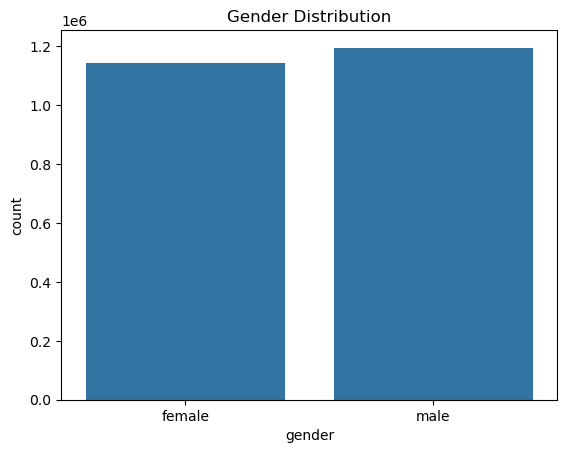

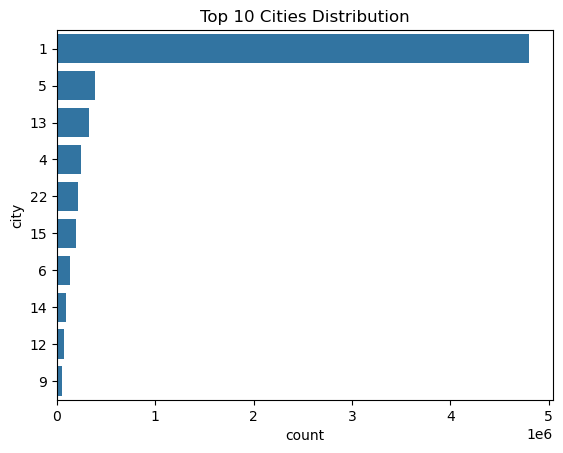

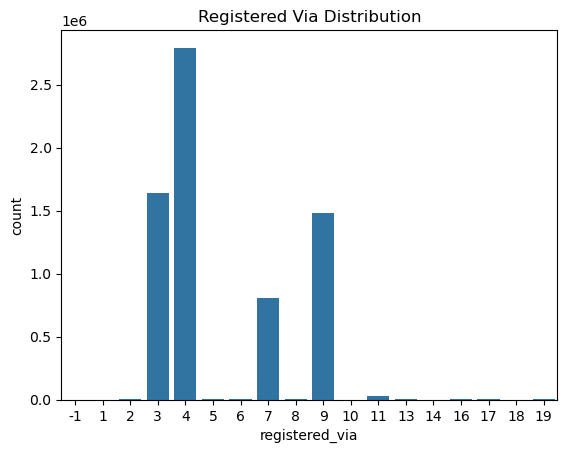

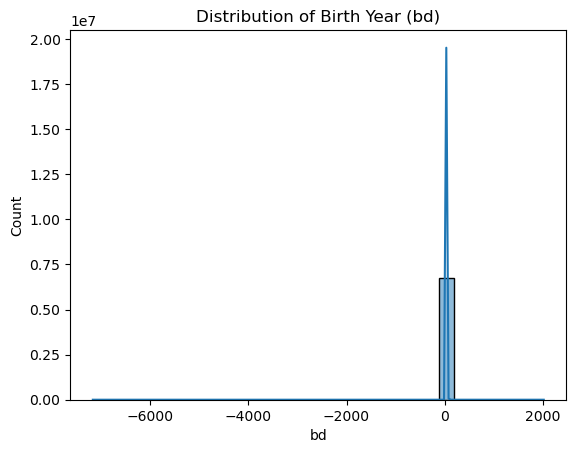

In [10]:
# 4. Key Variables Distribution 

# Categorical variables distribution

# print gender distribution
print("\nGender distribution:")
print(members['gender'].value_counts(dropna=False))

# print city distribution (top 10)
print("\nCity distribution (top 10):")
print(members['city'].value_counts().head(10))

# print registered via distribution
print("\nRegistered via distribution:")
print(members['registered_via'].value_counts())

# plot gender distribution
sns.countplot(x='gender', data=members)
plt.title("Gender Distribution")
plt.show()

# plot city distribution (top 10)
top_cities = members['city'].value_counts().head(10).index
sns.countplot(y='city', data=members[members['city'].isin(top_cities)], order=top_cities)
plt.title("Top 10 Cities Distribution")
plt.show()

# plot registered via distribution
sns.countplot(x='registered_via', data=members)
plt.title("Registered Via Distribution")
plt.show()

# numerical variables distribution
# plot distribution of birth year (bd)
sns.histplot(members['bd'], bins=30, kde=True)
plt.title("Distribution of Birth Year (bd)")
plt.show()

Members Initial EDA Note: age looks strange (many 0, negative and large values); gender has many missing values (~65%); user id seems unique; registration date is not in datetime format; some numeric columns represent categories and will be treated as categorical variables.

##### 1.2.3. Transactions (Initial EDA)

In [11]:
# 1. Load transactions_v2.csv dataset
transactions = pd.read_csv("C:/Users/pauli/OneDrive/Documentos/GitHub/Customer-Churn-Intelligence-System/data/raw/transactions_v2.csv") 

In [12]:
# 2. Dataset Structure
print("Dataset info:")
transactions.info()

print(f"\nDataset shape: {transactions.shape}")

print(f"\nDataset columns: {list(transactions.columns)}")

print(f"\nDataset datatypes:\n{transactions.dtypes}")

# number of unique values in each column
print("\nNumber of unique values in each column:")
print(transactions.nunique())

# print dataset unique values per column
print("\nUnique values in each column:")
for col in transactions.columns:
    unique_values = transactions[col].unique()
    print(f"{col}: {unique_values[:5]}{'...' if len(unique_values) > 5 else ''}")

# identify numerical and categorical columns
numerical_cols = transactions.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = transactions.select_dtypes(include=['object']).columns

print(f"\nNumerical columns: {list(numerical_cols)}")
print(f"\nCategorical columns: {list(categorical_cols)}")

# print first few rows of the dataset
pd.set_option('display.max_columns', None)
transactions.head()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1431009 entries, 0 to 1431008
Data columns (total 9 columns):
 #   Column                  Non-Null Count    Dtype 
---  ------                  --------------    ----- 
 0   msno                    1431009 non-null  object
 1   payment_method_id       1431009 non-null  int64 
 2   payment_plan_days       1431009 non-null  int64 
 3   plan_list_price         1431009 non-null  int64 
 4   actual_amount_paid      1431009 non-null  int64 
 5   is_auto_renew           1431009 non-null  int64 
 6   transaction_date        1431009 non-null  int64 
 7   membership_expire_date  1431009 non-null  int64 
 8   is_cancel               1431009 non-null  int64 
dtypes: int64(8), object(1)
memory usage: 98.3+ MB

Dataset shape: (1431009, 9)

Dataset columns: ['msno', 'payment_method_id', 'payment_plan_days', 'plan_list_price', 'actual_amount_paid', 'is_auto_renew', 'transaction_date', 'membership_expire_date', 'is_cancel']

Dataset datat

,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,++6eU4LsQ3UQ20ILS7d99XK8WbiVgbyYL4FUgzZR134=,32,90,298,298,0,20170131,20170504,0
1,++lvGPJOinuin/8esghpnqdljm6NXS8m8Zwchc7gOeA=,41,30,149,149,1,20150809,20190412,0
2,+/GXNtXWQVfKrEDqYAzcSw2xSPYMKWNj22m+5XkVQZc=,36,30,180,180,1,20170303,20170422,0
3,+/w1UrZwyka4C9oNH3+Q8fUf3fD8R3EwWrx57ODIsqk=,36,30,180,180,1,20170329,20170331,1
4,+00PGzKTYqtnb65mPKPyeHXcZEwqiEzktpQksaaSC3c=,41,30,99,99,1,20170323,20170423,0


In [13]:
# 3. Data Quality Assessment

# check for missing values
print("\nNumber of missing values in each column:")
print(transactions.isnull().sum())

# check percentage of missing values in each column
print("\nPercentage of missing values in each column:")
print((transactions.isnull().sum() / len(transactions) * 100).round(2))

# check for duplicates in user id
print(f"\nDuplicated values in msno column: {transactions['msno'].duplicated().sum()}")

# check for duplicated rows
print(f"\nDuplicated rows in dataset: {transactions.duplicated().sum()}")

# statistical summary only for true numerical variables
numerical_cols = ['payment_plan_days', 'plan_list_price', 'actual_amount_paid']

print("\nStatistical summary (numerical variables only):")
print(transactions[numerical_cols].describe())

# check min and max values for key columns
print("\nMin and max values:")
print(transactions[numerical_cols].agg(['min', 'max']))



Number of missing values in each column:
msno                      0
payment_method_id         0
payment_plan_days         0
plan_list_price           0
actual_amount_paid        0
is_auto_renew             0
transaction_date          0
membership_expire_date    0
is_cancel                 0
dtype: int64

Percentage of missing values in each column:
msno                      0.0
payment_method_id         0.0
payment_plan_days         0.0
plan_list_price           0.0
actual_amount_paid        0.0
is_auto_renew             0.0
transaction_date          0.0
membership_expire_date    0.0
is_cancel                 0.0
dtype: float64

Duplicated values in msno column: 233959

Duplicated rows in dataset: 0

Statistical summary (numerical variables only):
       payment_plan_days  plan_list_price  actual_amount_paid
count       1.431009e+06     1.431009e+06        1.431009e+06
mean        6.601770e+01     2.817870e+02        2.813172e+02
std         1.024864e+02     4.351861e+02        4.354


Cancellation distribution:
is_cancel
0    1395876
1      35133
Name: count, dtype: int64

Auto-renew distribution:
is_auto_renew
1    1123775
0     307234
Name: count, dtype: int64

Payment method distribution (top 10):
payment_method_id
41    696696
39    137120
38    115875
32    100982
36     90844
40     82747
37     40414
34     31099
29     24957
30     21182
Name: count, dtype: int64


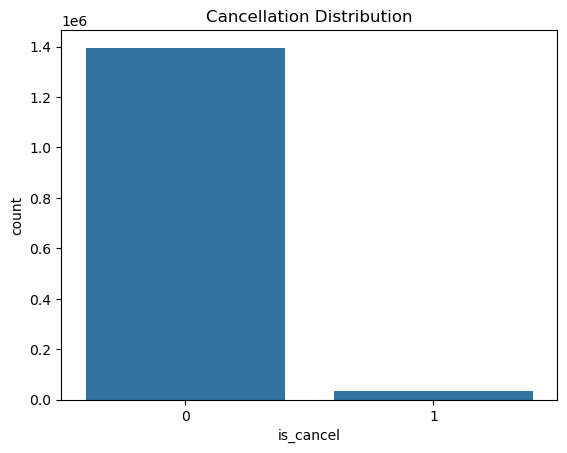

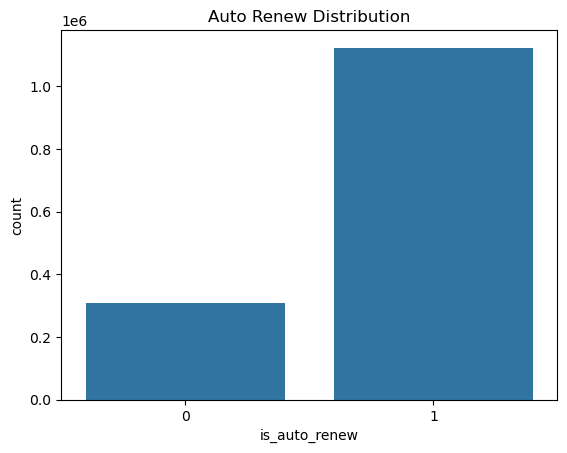

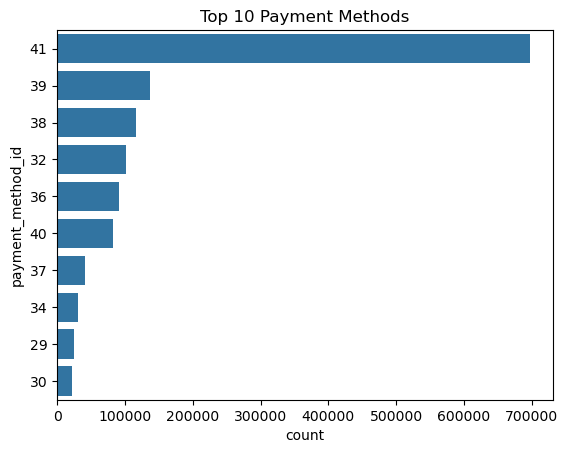


Payment plan days distribution:

Plan list price distribution:
count    1.431009e+06
mean     2.817870e+02
std      4.351861e+02
min      0.000000e+00
25%      9.900000e+01
50%      1.490000e+02
75%      1.490000e+02
max      2.000000e+03
Name: plan_list_price, dtype: float64

Actual amount paid distribution:
count    1.431009e+06
mean     2.813172e+02
std      4.354200e+02
min      0.000000e+00
25%      9.900000e+01
50%      1.490000e+02
75%      1.490000e+02
max      2.000000e+03
Name: actual_amount_paid, dtype: float64


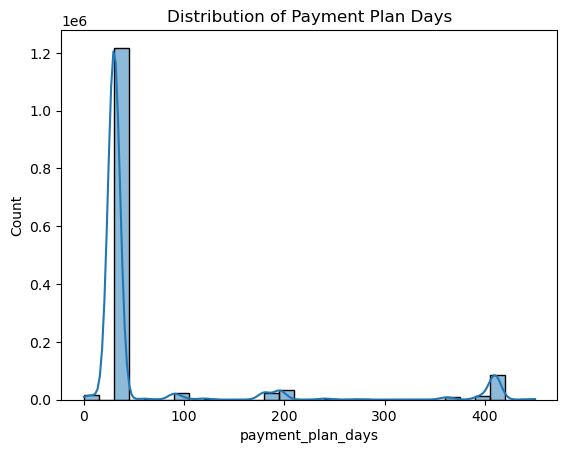

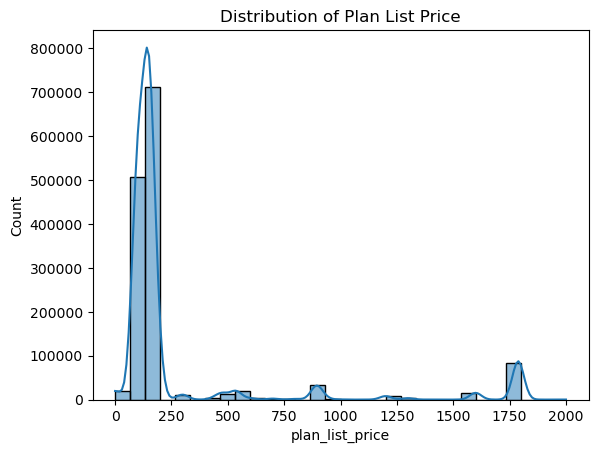

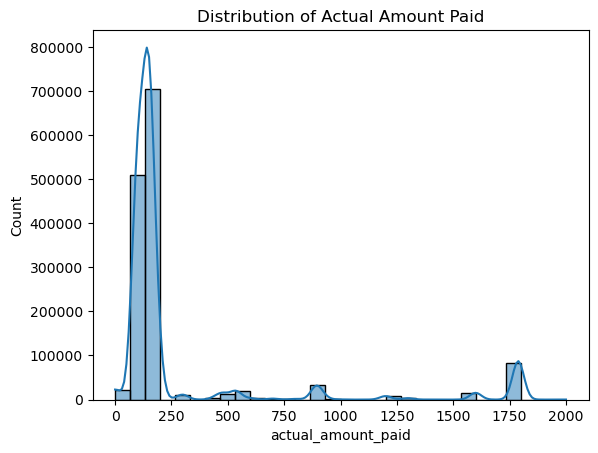

In [14]:
# 4. Key Variables Distribution 

# Categorical variables distribution

# print cancellation distribution
print("\nCancellation distribution:")
print(transactions['is_cancel'].value_counts())

# print auto-renew distribution
print("\nAuto-renew distribution:")
print(transactions['is_auto_renew'].value_counts())

# print payment method distribution (top 10)
print("\nPayment method distribution (top 10):")
print(transactions['payment_method_id'].value_counts().head(10))


# plot cancellation distribution
sns.countplot(x='is_cancel', data=transactions)
plt.title("Cancellation Distribution")
plt.show()

# plot auto-renew distribution
sns.countplot(x='is_auto_renew', data=transactions)
plt.title("Auto Renew Distribution")
plt.show()

# plot payment method distribution (top 10)
top_methods = transactions['payment_method_id'].value_counts().head(10).index
sns.countplot(
    y='payment_method_id',
    data=transactions[transactions['payment_method_id'].isin(top_methods)],
    order=top_methods
)
plt.title("Top 10 Payment Methods")
plt.show()


# Numerical variables distribution

# print payment plan days distribution
print("\nPayment plan days distribution:")

# print plan list price distribution
print("\nPlan list price distribution:")
print(transactions['plan_list_price'].describe())

# print actual amount paid distribution
print("\nActual amount paid distribution:")
print(transactions['actual_amount_paid'].describe())

# plot payment plan days
sns.histplot(transactions['payment_plan_days'], bins=30, kde=True)
plt.title("Distribution of Payment Plan Days")
plt.show()

# plot list price
sns.histplot(transactions['plan_list_price'], bins=30, kde=True)
plt.title("Distribution of Plan List Price")
plt.show()

# plot actual amount paid
sns.histplot(transactions['actual_amount_paid'], bins=30, kde=True)
plt.title("Distribution of Actual Amount Paid")
plt.show()


Transactions initial EDA note: multiple transactions per user; 
no duplicated rows; cancellation and auto-renew seem relevant for churn; payment variables show different values across transactions

##### 1.2.4. User Logs (Initial EDA)

In [15]:
# 1. Load user_logs_v2.csv dataset
user_logs = pd.read_csv("C:/Users/pauli/OneDrive/Documentos/GitHub/Customer-Churn-Intelligence-System/data/raw/user_logs_v2.csv")

In [16]:
# 2. Dataset Structure
print("Dataset info:")
user_logs.info()

print(f"\nDataset shape: {user_logs.shape}")

print(f"\nDataset columns: {list(user_logs.columns)}")

print(f"\nDataset datatypes:\n{user_logs.dtypes}")

# number of unique values in each column
print("\nNumber of unique values in each column:")
print(user_logs.nunique())

# print dataset unique values per column (limited to avoid overload)
print("\nUnique values in each column (sample):")
for col in user_logs.columns:
    unique_values = user_logs[col].unique()
    print(f"{col}: {unique_values[:5]}{'...' if len(unique_values) > 5 else ''}")

# identify numerical and categorical columns
numerical_cols = user_logs.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = user_logs.select_dtypes(include=['object']).columns

print(f"\nNumerical columns: {list(numerical_cols)}")
print(f"\nCategorical columns: {list(categorical_cols)}")

# print first few rows of the dataset
pd.set_option('display.max_columns', None)
user_logs.head()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18396362 entries, 0 to 18396361
Data columns (total 9 columns):
 #   Column      Dtype  
---  ------      -----  
 0   msno        object 
 1   date        int64  
 2   num_25      int64  
 3   num_50      int64  
 4   num_75      int64  
 5   num_985     int64  
 6   num_100     int64  
 7   num_unq     int64  
 8   total_secs  float64
dtypes: float64(1), int64(7), object(1)
memory usage: 1.2+ GB

Dataset shape: (18396362, 9)

Dataset columns: ['msno', 'date', 'num_25', 'num_50', 'num_75', 'num_985', 'num_100', 'num_unq', 'total_secs']

Dataset datatypes:
msno           object
date            int64
num_25          int64
num_50          int64
num_75          int64
num_985         int64
num_100         int64
num_unq         int64
total_secs    float64
dtype: object

Number of unique values in each column:
msno           1103894
date                31
num_25             743
num_50             356
num_75             193
num_9

,msno,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
0,u9E91QDTvHLq6NXjEaWv8u4QIqhrHk72kE+w31Gnhdg=,20170331,8,4,0,1,21,18,6309.273
1,nTeWW/eOZA/UHKdD5L7DEqKKFTjaAj3ALLPoAWsU8n0=,20170330,2,2,1,0,9,11,2390.699
2,2UqkWXwZbIjs03dHLU9KHJNNEvEkZVzm69f3jCS+uLI=,20170331,52,3,5,3,84,110,23203.337
3,ycwLc+m2O0a85jSLALtr941AaZt9ai8Qwlg9n0Nql5U=,20170331,176,4,2,2,19,191,7100.454
4,EGcbTofOSOkMmQyN1NMLxHEXJ1yV3t/JdhGwQ9wXjnI=,20170331,2,1,0,1,112,93,28401.558


In [17]:
# 3. Data Quality Assessment

# check for missing values
print("\nNumber of missing values in each column:")
print(user_logs.isnull().sum())

# check percentage of missing values in each column
print("\nPercentage of missing values in each column:")
print((user_logs.isnull().sum() / len(user_logs) * 100).round(2))

# check for duplicates in user id
print(f"\nDuplicated values in msno column: {user_logs['msno'].duplicated().sum()}")

# check for duplicated rows
print(f"\nDuplicated rows in dataset: {user_logs.duplicated().sum()}")

# statistical summary only for true numerical variables
numerical_cols = ['num_25','num_50','num_75','num_985','num_100','num_unq','total_secs']

print("\nStatistical summary (numerical variables only):")
print(user_logs[numerical_cols].describe())

# check min and max values for key columns
print("\nMin and max values:")
print(user_logs[numerical_cols].agg(['min', 'max']))


Number of missing values in each column:
msno          0
date          0
num_25        0
num_50        0
num_75        0
num_985       0
num_100       0
num_unq       0
total_secs    0
dtype: int64

Percentage of missing values in each column:
msno          0.0
date          0.0
num_25        0.0
num_50        0.0
num_75        0.0
num_985       0.0
num_100       0.0
num_unq       0.0
total_secs    0.0
dtype: float64

Duplicated values in msno column: 17292468

Duplicated rows in dataset: 0

Statistical summary (numerical variables only):
             num_25        num_50        num_75       num_985       num_100  \
count  1.839636e+07  1.839636e+07  1.839636e+07  1.839636e+07  1.839636e+07   
mean   6.191401e+00  1.508789e+00  9.413759e-01  1.079905e+00  3.028246e+01   
std    1.342827e+01  3.908539e+00  1.924840e+00  3.518409e+00  4.203641e+01   
min    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
25%    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+


Total seconds distribution:
count    1.839636e+07
mean     7.904814e+03
std      1.013632e+04
min      1.000000e-03
25%      1.959944e+03
50%      4.582990e+03
75%      9.848441e+03
max      9.194059e+06
Name: total_secs, dtype: float64

Unique songs distribution:
count    1.839636e+07
mean     2.903615e+01
std      3.219866e+01
min      1.000000e+00
25%      8.000000e+00
50%      1.800000e+01
75%      3.800000e+01
max      4.925000e+03
Name: num_unq, dtype: float64

Playback behavior distribution:
             num_25        num_50        num_75       num_985       num_100
count  1.839636e+07  1.839636e+07  1.839636e+07  1.839636e+07  1.839636e+07
mean   6.191401e+00  1.508789e+00  9.413759e-01  1.079905e+00  3.028246e+01
std    1.342827e+01  3.908539e+00  1.924840e+00  3.518409e+00  4.203641e+01
min    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
25%    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  7.000000e+00
50%    2.000000e+00  1.000000e+00  0.00

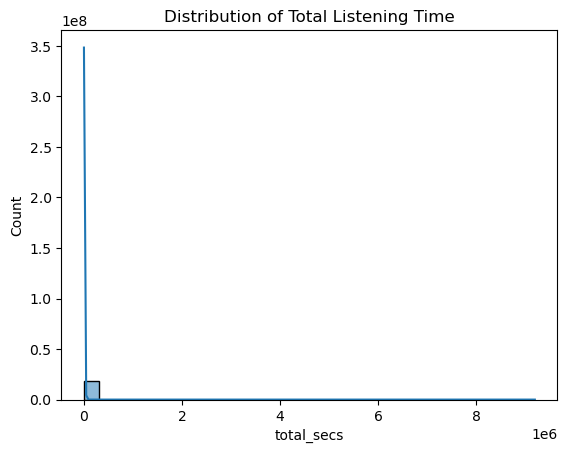

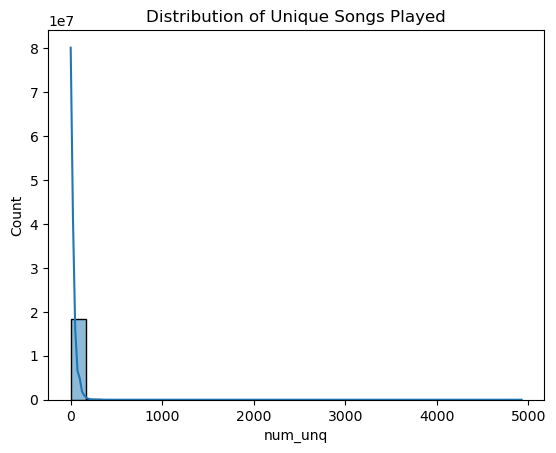

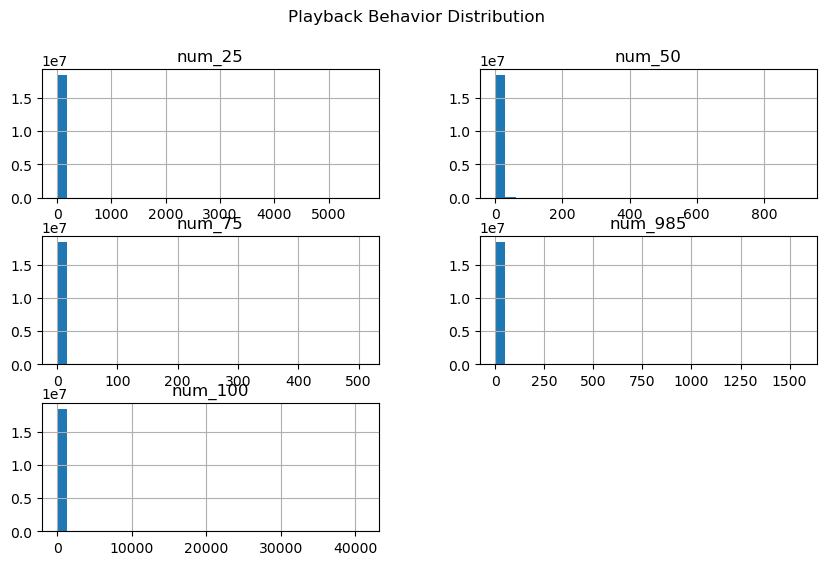

In [18]:
# 4. Key Variables Distribution 

# Numerical variables distribution

# print engagement variables distribution
print("\nTotal seconds distribution:")
print(user_logs['total_secs'].describe())

print("\nUnique songs distribution:")
print(user_logs['num_unq'].describe())

print("\nPlayback behavior distribution:")
print(user_logs[['num_25','num_50','num_75','num_985','num_100']].describe())


# plot total listening time
sns.histplot(user_logs['total_secs'], bins=30, kde=True)
plt.title("Distribution of Total Listening Time")
plt.show()

# plot unique songs
sns.histplot(user_logs['num_unq'], bins=30, kde=True)
plt.title("Distribution of Unique Songs Played")
plt.show()

# plot playback behavior
user_logs[['num_25','num_50','num_75','num_985','num_100']].hist(bins=30, figsize=(10,6))
plt.suptitle("Playback Behavior Distribution")
plt.show()

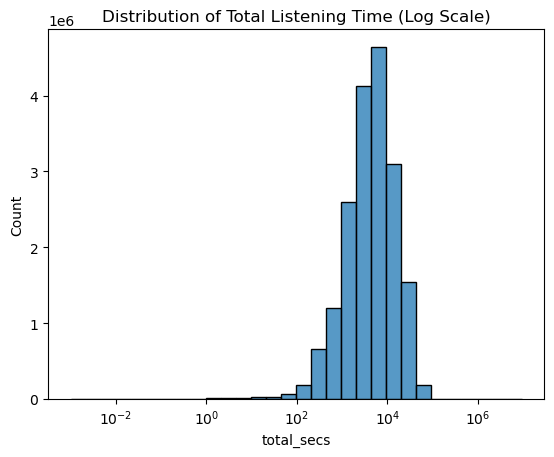

In [19]:
sns.histplot(user_logs['total_secs'], bins=30, log_scale=True)
plt.title("Distribution of Total Listening Time (Log Scale)")
plt.show()

User_logs initial EDA note: multiple records per user; no duplicated rows; user activity varies, with many low values and some very high engagement.

#### 1.3. Temporary merge For Initial Bivariate Analysis (with original variables only)

In [20]:
# Temporary merge for exploratory analysis (no transformations applied)
train_members = train.merge(members, on='msno', how='left')
print("\nMerged dataset info:")
train_members.info()

# print first few rows of the dataset
pd.set_option('display.max_columns', None)
train_members.head()


Merged dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970960 entries, 0 to 970959
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   msno                    970960 non-null  object 
 1   is_churn                970960 non-null  int64  
 2   city                    860967 non-null  float64
 3   bd                      860967 non-null  float64
 4   gender                  388905 non-null  object 
 5   registered_via          860967 non-null  float64
 6   registration_init_time  860967 non-null  float64
dtypes: float64(4), int64(1), object(2)
memory usage: 51.9+ MB


,msno,is_churn,city,bd,gender,registered_via,registration_init_time
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1,5.0,28.0,male,3.0,20131223.0
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1,13.0,20.0,male,3.0,20131223.0
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1,13.0,18.0,male,3.0,20131227.0
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1,1.0,0.0,NaN,7.0,20140109.0
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1,13.0,35.0,female,7.0,20140125.0


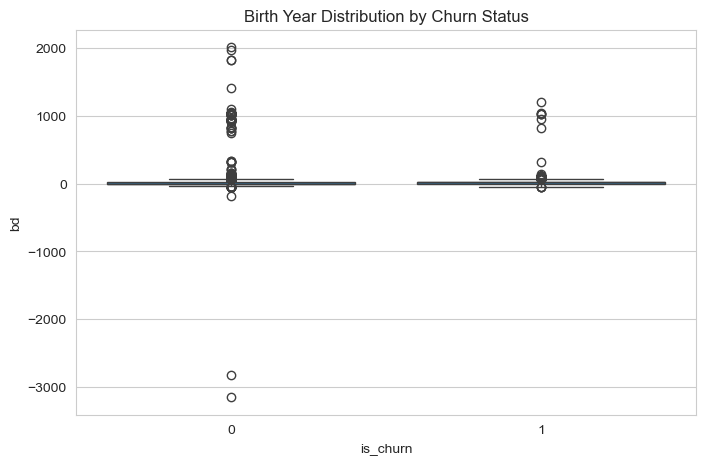

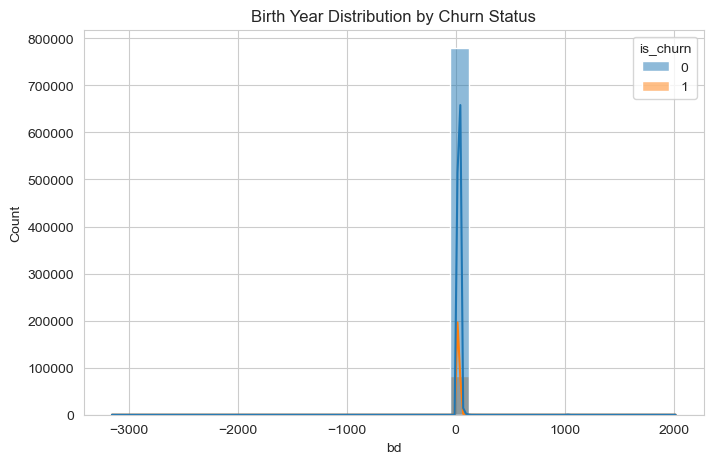

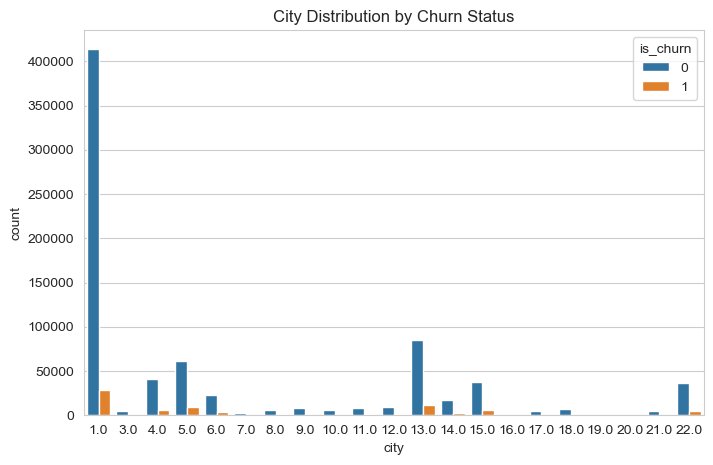

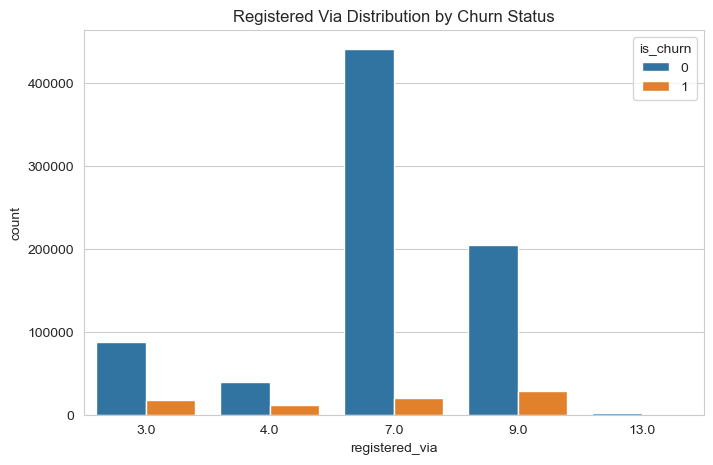

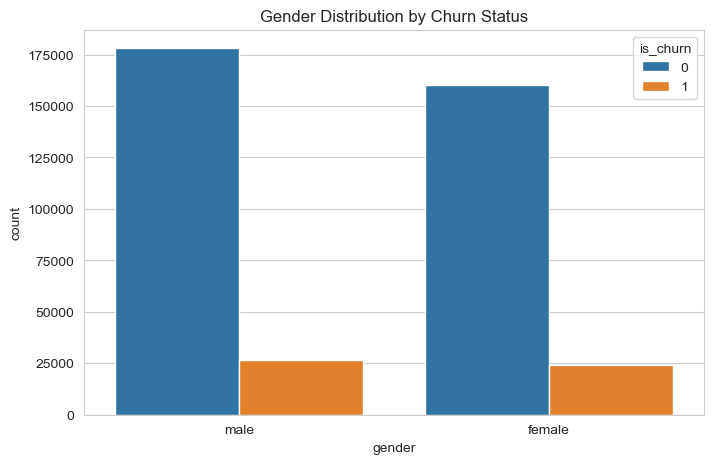

In [40]:
# print train_members bivariate plots 

# 1. bd - birth year by churn status
sns.boxplot(x='is_churn', y='bd', data=train_members)
plt.title("Birth Year Distribution by Churn Status")
plt.show()

# print histogram of birth year by churn status
sns.histplot(data=train_members, x='bd', hue='is_churn', bins=30, kde=True)
plt.title("Birth Year Distribution by Churn Status")
plt.show()

# 2. city by churn status
sns.countplot(x='city', hue='is_churn', data=train_members)
plt.title("City Distribution by Churn Status")
plt.show()

# 3. registered_via by churn status
sns.countplot(x='registered_via', hue='is_churn', data=train_members)
plt.title("Registered Via Distribution by Churn Status")
plt.show()

# 4. gender by churn status
sns.countplot(x='gender', hue='is_churn', data=train_members)
plt.title("Gender Distribution by Churn Status")
plt.show()


### **2. UNDERSTANDING THE BUSINESS PROBLEM**

#### 2.1. Temporary Data Engeniering For Busisness Problem Understanding (Initial EDA)

In [24]:
# 2.1.1 Aggregate user logs by msno to get total listening time and unique songs played per user

user_logs = pd.read_csv("C:/Users/pauli/OneDrive/Documentos/GitHub/Customer-Churn-Intelligence-System/data/raw/user_logs_v2.csv")

user_logs_agg = user_logs.groupby('msno').agg({
    'total_secs': 'sum',
    'num_unq': 'sum'
}).reset_index()
print("\nAggregated user logs info:")
print(user_logs_agg.info())
print(user_logs_agg.head())


Aggregated user logs info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1103894 entries, 0 to 1103893
Data columns (total 3 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   msno        1103894 non-null  object 
 1   total_secs  1103894 non-null  float64
 2   num_unq     1103894 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 25.3+ MB
None
                                           msno  total_secs  num_unq
0  +++IZseRRiQS9aaSkH6cMYU6bGDcxUieAi/tH67sC5s=  117907.425      530
1  +++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o=  192527.892      885
2  +++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=  115411.260      468
3  +++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=  149896.558      828
4  ++/9R3sX37CjxbY/AaGvbwr3QkwElKBCtSvVzhCBDOk=  116433.247      230


In [65]:
# 2.1.2 Aggregate transactions by msno
# Create customer-level transaction features

transactions = pd.read_csv(
    "C:/Users/pauli/OneDrive/Documentos/GitHub/Customer-Churn-Intelligence-System/data/raw/transactions_v2.csv"
)

# Clean and convert date columns
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
    .astype(str)
    .str.replace(".0", "", regex=False),
    format="%Y%m%d",
    errors="coerce"
)

transactions["membership_expire_date"] = pd.to_datetime(
    transactions["membership_expire_date"]
    .astype(str)
    .str.replace(".0", "", regex=False),
    format="%Y%m%d",
    errors="coerce"
)

# Check conversion
print("\nMissing values after date conversion:")
print("transaction_date:", transactions["transaction_date"].isna().sum())
print("membership_expire_date:", transactions["membership_expire_date"].isna().sum())

# Aggregate
transactions_agg = transactions.groupby("msno").agg({
    "actual_amount_paid": ["sum", "mean"],
    "payment_plan_days": ["sum", "mean"],
    "plan_list_price": "mean",
    "is_auto_renew": ["mean", "max"],
    "is_cancel": ["mean", "max"],
    "transaction_date": ["count", "min", "max"],
    "membership_expire_date": "max"
}).reset_index()

# Flatten column names
transactions_agg.columns = [
    "msno",
    "total_amount_paid",
    "avg_amount_paid",
    "total_payment_plan_days",
    "avg_payment_plan_days",
    "avg_plan_list_price",
    "auto_renew_rate",
    "has_auto_renew",
    "cancel_rate",
    "has_cancelled",
    "transaction_count",
    "first_transaction_date",
    "last_transaction_date",
    "membership_expire_date"
]

print("\nAggregated transactions info:")
print(transactions_agg.info())

print("\nFirst rows of aggregated transactions:")
print(transactions_agg.head())






Missing values after date conversion:
transaction_date: 0
membership_expire_date: 0

Aggregated transactions info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197050 entries, 0 to 1197049
Data columns (total 14 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   msno                     1197050 non-null  object        
 1   total_amount_paid        1197050 non-null  int64         
 2   avg_amount_paid          1197050 non-null  float64       
 3   total_payment_plan_days  1197050 non-null  int64         
 4   avg_payment_plan_days    1197050 non-null  float64       
 5   avg_plan_list_price      1197050 non-null  float64       
 6   auto_renew_rate          1197050 non-null  float64       
 7   has_auto_renew           1197050 non-null  int64         
 8   cancel_rate              1197050 non-null  float64       
 9   has_cancelled            1197050 non-null  int64         
 10  transactio

In [66]:
# 2.1.3. Merge all datasets together for final exploratory analysis (no transformations applied)   

df = train.copy()
df = df.merge(members, on='msno', how='left')
df = df.merge(transactions_agg, on='msno', how='left')
df = df.merge(user_logs_agg, on='msno', how='left')
print("\nFinal merged dataset info:")
print(df.info())

# print first few rows of the dataset
pd.set_option('display.max_columns', None)
df.head()


Final merged dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970960 entries, 0 to 970959
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   msno                     970960 non-null  object        
 1   is_churn                 970960 non-null  int64         
 2   city                     860967 non-null  float64       
 3   bd                       860967 non-null  float64       
 4   gender                   388905 non-null  object        
 5   registered_via           860967 non-null  float64       
 6   registration_init_time   860967 non-null  float64       
 7   total_amount_paid        933578 non-null  float64       
 8   avg_amount_paid          933578 non-null  float64       
 9   total_payment_plan_days  933578 non-null  float64       
 10  avg_payment_plan_days    933578 non-null  float64       
 11  avg_plan_list_price      933578 non-null  float64 

,msno,is_churn,city,bd,gender,registered_via,registration_init_time,total_amount_paid,avg_amount_paid,total_payment_plan_days,avg_payment_plan_days,avg_plan_list_price,auto_renew_rate,has_auto_renew,cancel_rate,has_cancelled,transaction_count,first_transaction_date,last_transaction_date,membership_expire_date,total_secs,num_unq
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1,5.0,28.0,male,3.0,20131223.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,80598.557,348.0
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1,13.0,20.0,male,3.0,20131223.0,180.0,180.0,30.0,30.0,180.0,0.0,0.0,0.000,0.0,1.0,2017-03-11,2017-03-11,2017-04-11,6986.509,30.0
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1,13.0,18.0,male,3.0,20131227.0,300.0,150.0,150.0,75.0,150.0,0.0,0.0,0.000,0.0,2.0,2017-03-11,2017-03-14,2017-06-15,67810.467,432.0
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1,1.0,0.0,NaN,7.0,20140109.0,1490.0,149.0,300.0,30.0,149.0,1.0,1.0,0.000,0.0,10.0,2015-08-08,2015-12-08,2018-01-08,NaN,NaN
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1,13.0,35.0,female,7.0,20140125.0,792.0,99.0,240.0,30.0,99.0,1.0,1.0,0.125,1.0,8.0,2016-10-01,2017-03-16,2017-09-18,239882.241,548.0


#### 2.2. Initial Correlation Analysis

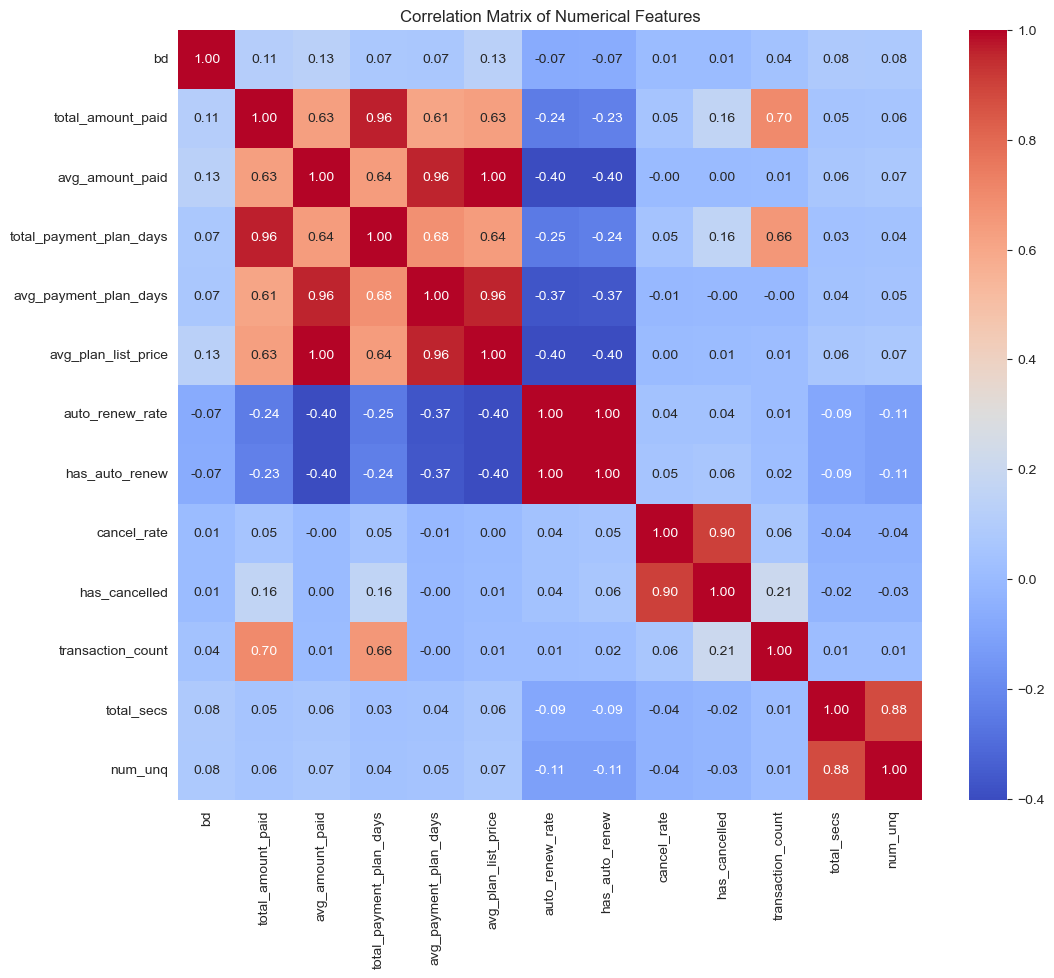

In [67]:
# Correlation analysis (numerical variables only)
numerical_cols = [
    'bd', 'total_amount_paid', 'avg_amount_paid', 'total_payment_plan_days',
    'avg_payment_plan_days', 'avg_plan_list_price', 'auto_renew_rate',
    'has_auto_renew', 'cancel_rate', 'has_cancelled', 'transaction_count',
    'total_secs', 'num_unq'
]
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

#### 2.3. Understanding Key Business Questions

In [68]:
# Choose plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

##### 2.3.1. Key Question 1: Which customer segments show higher churn rates?


Churn rate by gender:
gender
female    0.129866
male      0.129037
Name: is_churn, dtype: float64


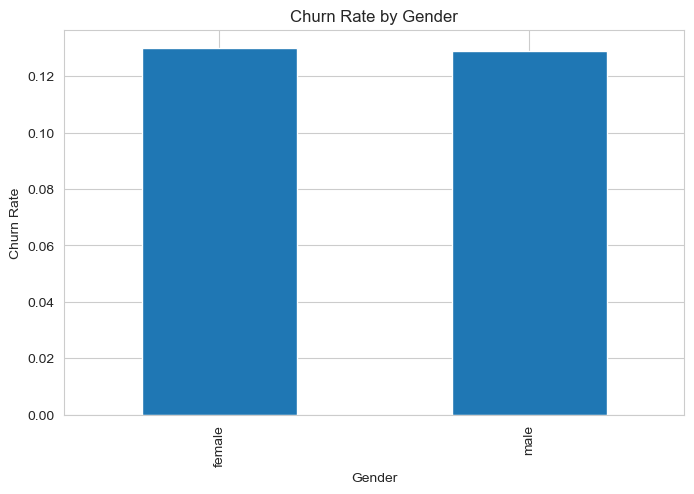


Percentage of churned customers by gender:
gender
female    12.99
male      12.90
Name: is_churn, dtype: float64


In [69]:
# Churn rate by gender
churn_by_gender = df.groupby('gender')['is_churn'].mean()
print("\nChurn rate by gender:")
print(churn_by_gender)

# plot churn rate by gender
churn_by_gender.plot(kind='bar')
plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate")
plt.show()

# print percentage of churne rate by gender
print("\nPercentage of churned customers by gender:")
print((churn_by_gender * 100).round(2))                 


Churn rate by auto-renewal status:
auto_renew_rate
0.000000    0.302611
0.083333    1.000000
0.160714    1.000000
0.200000    0.600000
0.227273    1.000000
0.250000    0.750000
0.285714    1.000000
0.307692    1.000000
0.333333    0.527397
0.400000    0.666667
0.500000    0.408994
0.600000    0.833333
0.625000    0.500000
0.640000    1.000000
0.666667    0.467470
0.750000    0.454545
0.777778    1.000000
0.800000    0.413793
0.833333    0.227848
0.857143    0.800000
0.866667    1.000000
0.875000    0.800000
0.882353    0.000000
0.888889    0.888889
0.900000    1.000000
0.909091    1.000000
0.916667    1.000000
0.923077    0.818182
0.928571    0.500000
0.933333    1.000000
0.937500    0.750000
0.941176    0.600000
0.945946    1.000000
0.947368    0.000000
0.950000    1.000000
0.952381    0.750000
0.954545    1.000000
0.956522    1.000000
0.958333    1.000000
0.961538    1.000000
0.962963    1.000000
0.968750    1.000000
0.970588    1.000000
0.972222    1.000000
1.000000    0.037912
Nam

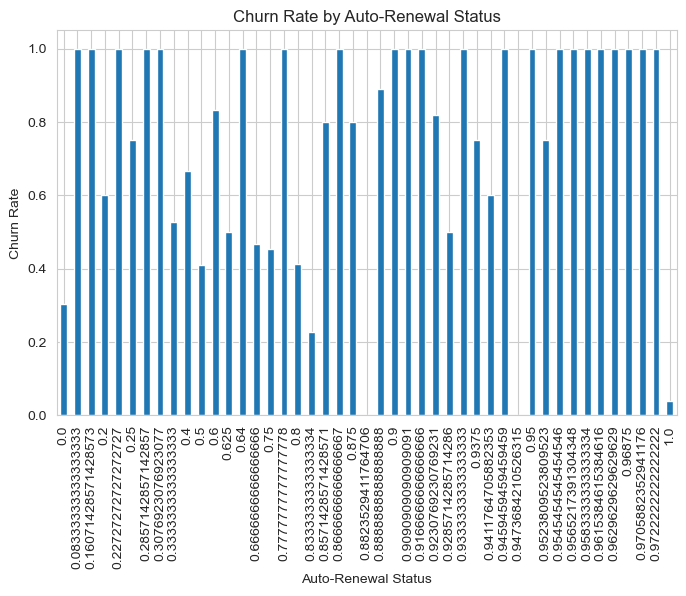


Percentage of churned customers by auto-renewal status:
auto_renew_rate
0.083333    100.00
0.227273    100.00
0.160714    100.00
0.307692    100.00
0.285714    100.00
0.968750    100.00
0.970588    100.00
0.916667    100.00
0.909091    100.00
0.900000    100.00
0.866667    100.00
0.777778    100.00
0.640000    100.00
0.972222    100.00
0.958333    100.00
0.961538    100.00
0.962963    100.00
0.950000    100.00
0.954545    100.00
0.945946    100.00
0.933333    100.00
0.956522    100.00
0.888889     88.89
0.600000     83.33
0.923077     81.82
0.875000     80.00
0.857143     80.00
0.250000     75.00
0.952381     75.00
0.937500     75.00
0.400000     66.67
0.200000     60.00
0.941176     60.00
0.333333     52.74
0.928571     50.00
0.625000     50.00
0.666667     46.75
0.750000     45.45
0.800000     41.38
0.500000     40.90
0.000000     30.26
0.833333     22.78
1.000000      3.79
0.882353      0.00
0.947368      0.00
Name: is_churn, dtype: float64


In [70]:
# Churn by auto-renewal status
churn_by_auto_renew = df.groupby('auto_renew_rate')['is_churn'].mean()
print("\nChurn rate by auto-renewal status:")
print(churn_by_auto_renew)

# plot churn rate by auto-renewal status
churn_by_auto_renew.plot(kind='bar')
plt.title("Churn Rate by Auto-Renewal Status")
plt.xlabel("Auto-Renewal Status")
plt.ylabel("Churn Rate")
plt.show()

# print percentage of churned customers by auto-renewal status in descending order
print("\nPercentage of churned customers by auto-renewal status:")
print((churn_by_auto_renew * 100).round(2).sort_values(ascending=False))


Churn rate by cancellation status:
has_cancelled
0.0    0.042624
1.0    0.602630
Name: is_churn, dtype: float64


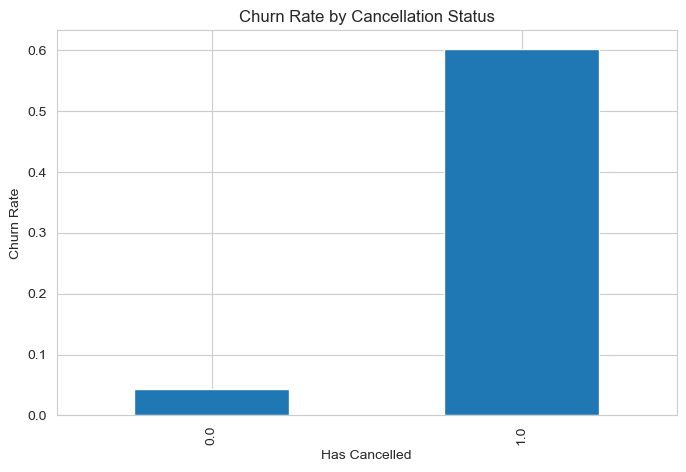


Percentage of churned customers by cancellation status:
has_cancelled
1.0    60.26
0.0     4.26
Name: is_churn, dtype: float64


In [71]:
# chrurn rate by cancellation status
churn_by_cancel = df.groupby('has_cancelled')['is_churn'].mean()
print("\nChurn rate by cancellation status:")
print(churn_by_cancel)

# plot churn rate by cancellation status
churn_by_cancel.plot(kind='bar')
plt.title("Churn Rate by Cancellation Status")
plt.xlabel("Has Cancelled")
plt.ylabel("Churn Rate")
plt.show()

# print percentage of churned customers by cancellation status in descending order
print("\nPercentage of churned customers by cancellation status:")
print((churn_by_cancel * 100).round(2).sort_values(ascending=False))


Churn rate by registration method:
registered_via
3.0     0.172254
4.0     0.231022
7.0     0.044732
9.0     0.126832
13.0    0.098791
Name: is_churn, dtype: float64


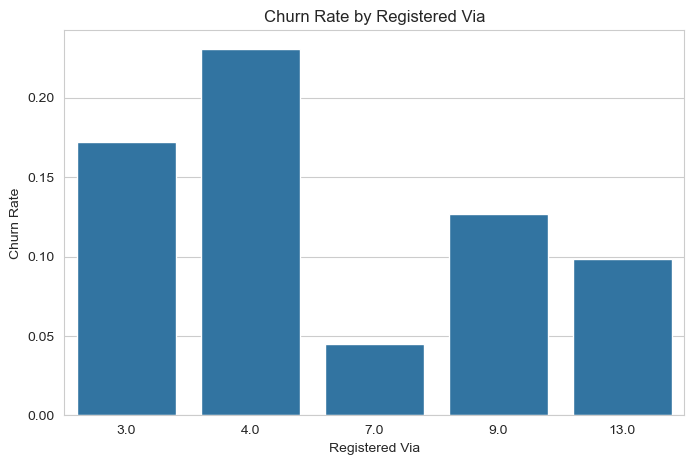


Percentage of churned customers by registration method:
registered_via
4.0     23.10
3.0     17.23
9.0     12.68
13.0     9.88
7.0      4.47
Name: is_churn, dtype: float64


In [72]:
# churn rate by registered_via (registration method)
churn_by_registered_via = df.groupby('registered_via')['is_churn'].mean()
print("\nChurn rate by registration method:")
print(churn_by_registered_via)

# plot churn rate by registered_via
sns.barplot(x=churn_by_registered_via.index, y=churn_by_registered_via.values)
plt.title("Churn Rate by Registered Via")
plt.xlabel("Registered Via")
plt.ylabel("Churn Rate")
plt.show()

# print percentage of churne rate by registered_via in descending order
print("\nPercentage of churned customers by registration method:")
print((churn_by_registered_via * 100).round(2).sort_values(ascending=False))


Churn rate by city:
city
21.0    0.147144
12.0    0.139243
8.0     0.134537
3.0     0.132885
10.0    0.132612
5.0     0.131997
4.0     0.129036
6.0     0.128827
15.0    0.128233
9.0     0.125971
22.0    0.125836
13.0    0.123023
19.0    0.121429
11.0    0.119939
14.0    0.118423
18.0    0.117171
7.0     0.111614
16.0    0.110169
20.0    0.106352
17.0    0.104273
1.0     0.064056
Name: is_churn, dtype: float64


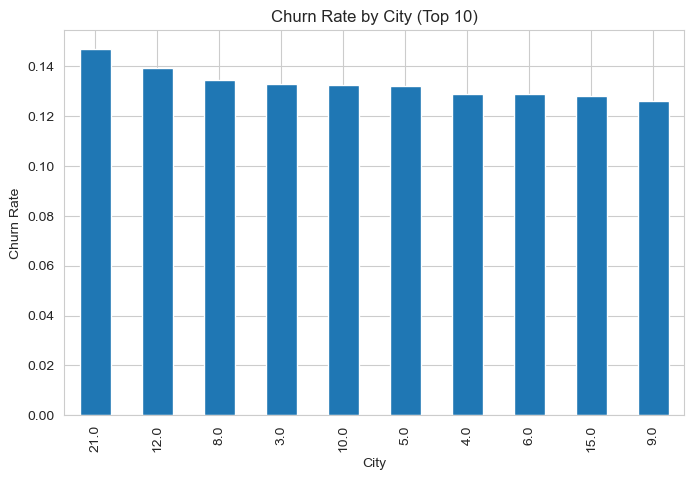


Percentage of churned customers by city (top 10):
city
21.0    14.71
12.0    13.92
8.0     13.45
3.0     13.29
10.0    13.26
5.0     13.20
4.0     12.90
6.0     12.88
15.0    12.82
9.0     12.60
Name: is_churn, dtype: float64


In [73]:
# Churn rate by city
churn_by_city = df.groupby('city')['is_churn'].mean().sort_values(ascending=False)
print("\nChurn rate by city:")
print(churn_by_city)

# plot churn rate by city (top 10)
top_cities = churn_by_city.head(10).index
churn_by_city.head(10).plot(kind='bar')
plt.title("Churn Rate by City (Top 10)")
plt.xlabel("City")
plt.ylabel("Churn Rate")
plt.show()

# print percentage of churne rate by city (top 10)
print("\nPercentage of churned customers by city (top 10):")
print((churn_by_city.head(10) * 100).round(2))

##### 2.3.2. Key Question 2: What behavioral patterns are associated with churn?

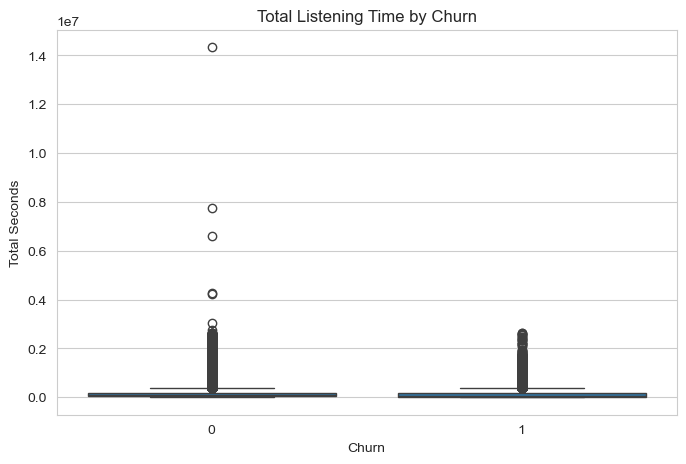

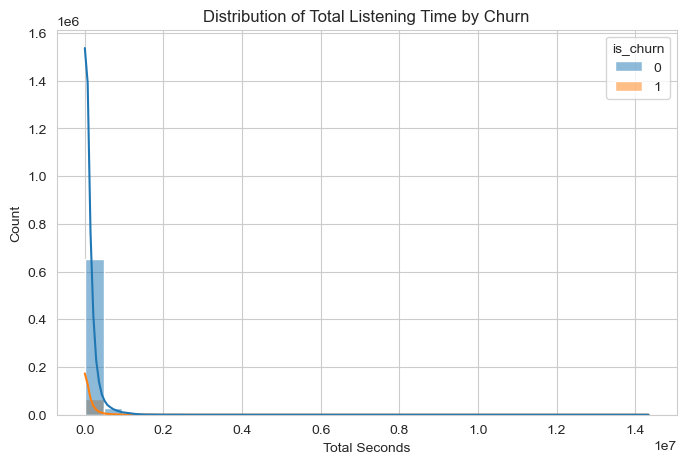


Average total listening time by churn status:
is_churn
0    141113.08
1    126291.23
Name: total_secs, dtype: float64

Percentage of average total listening time by churn status:
is_churn
0    52.77
1    47.23
Name: total_secs, dtype: float64


In [74]:
# 1 Total listening time vs churn
# Compare total listening time by churn
sns.boxplot(data=df, x='is_churn', y='total_secs')
plt.title("Total Listening Time by Churn")
plt.xlabel("Churn")
plt.ylabel("Total Seconds")
plt.show()

# Distribution of listening time by churn
sns.histplot(data=df, x='total_secs', hue='is_churn', bins=30, kde=True)
plt.title("Distribution of Total Listening Time by Churn")
plt.xlabel("Total Seconds")
plt.ylabel("Count")
plt.show()

# print average total listening time by churn status rounded to 2 decimal places
avg_listening_time = df.groupby('is_churn')['total_secs'].mean().round(2)
print("\nAverage total listening time by churn status:")
print(avg_listening_time)

# print percentage of average total listening time by churn status
print("\nPercentage of average total listening time by churn status:")
print((avg_listening_time / avg_listening_time.sum() * 100).round(2))

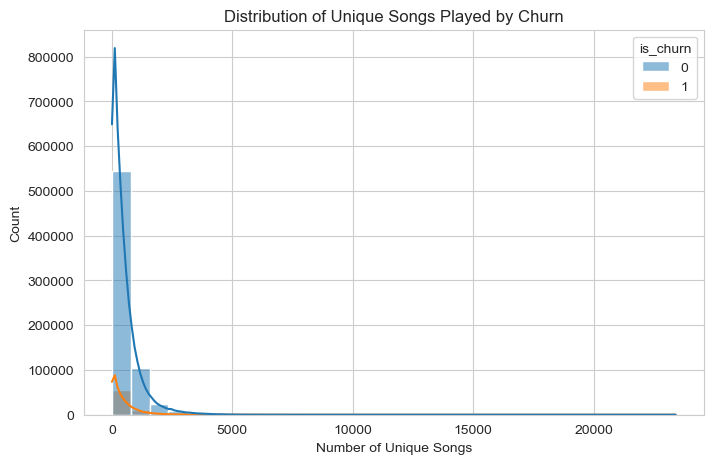


Average number of unique songs by churn status:
is_churn
0    515.73
1    472.74
Name: num_unq, dtype: float64

Percentage of average number of unique songs by churn status:
is_churn
0    52.17
1    47.83
Name: num_unq, dtype: float64


In [75]:
# 2 Number of unique songs vs churn
# Compare unique songs listened to by churn
sns.histplot(data=df, x='num_unq', hue='is_churn', bins=30, kde=True)
plt.title("Distribution of Unique Songs Played by Churn")
plt.xlabel("Number of Unique Songs")
plt.ylabel("Count")
plt.show()

# Average number of unique songs by churn rounded to 2 decimal places   
avg_unique_songs = df.groupby('is_churn')['num_unq'].mean().round(2)

print("\nAverage number of unique songs by churn status:")
print(avg_unique_songs)

# Percentage
print("\nPercentage of average number of unique songs by churn status:")
print((avg_unique_songs / avg_unique_songs.sum() * 100).round(2))

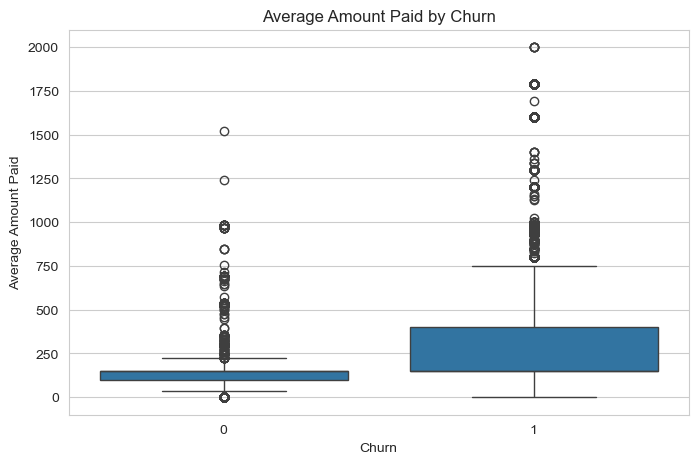

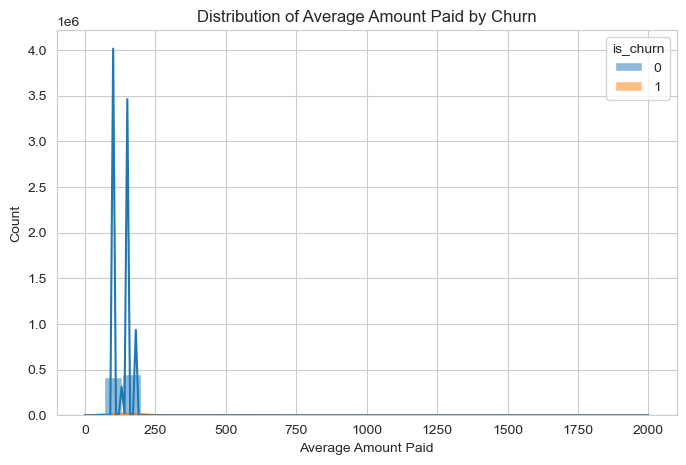


Average average amount paid by churn status:
is_churn
0    129.00
1    367.03
Name: avg_amount_paid, dtype: float64

Percentage of average actual amount paid by churn status:
is_churn
0    26.01
1    73.99
Name: avg_amount_paid, dtype: float64


In [76]:
# 3 Payment amount vs churn
# Compare actual amount paid by churn
sns.boxplot(data=df, x='is_churn', y='avg_amount_paid')
plt.title("Average Amount Paid by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Amount Paid")
plt.show()

# Distribution of average amount paid by churn
sns.histplot(data=df, x='avg_amount_paid', hue='is_churn', bins=30, kde=True)

plt.title("Distribution of Average Amount Paid by Churn")
plt.xlabel("Average Amount Paid")
plt.ylabel("Count")
plt.show()

# print average average amount paid by churn status rounded to 2 decimal places
avg_amount_paid = df.groupby('is_churn')['avg_amount_paid'].mean().round(
2)
print("\nAverage average amount paid by churn status:")
print(avg_amount_paid)

# print percentage of average actual amount paid by churn status
print("\nPercentage of average actual amount paid by churn status:")
print((avg_amount_paid / avg_amount_paid.sum() * 100).round(2))



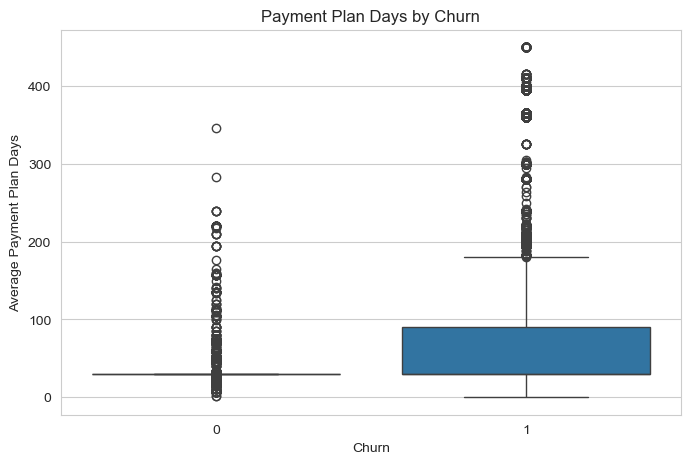

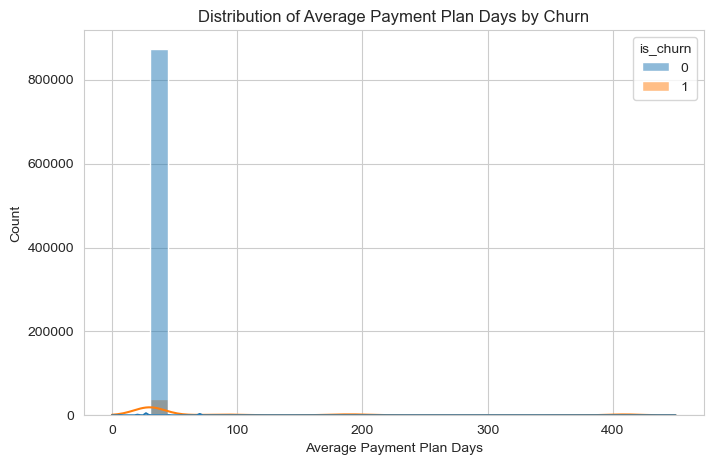


Average payment plan days by churn status:
is_churn
0    30.03
1    88.68
Name: avg_payment_plan_days, dtype: float64

Percentage of average payment plan days by churn status:
is_churn
0    25.3
1    74.7
Name: avg_payment_plan_days, dtype: float64


In [77]:
# 4 Plan duration vs churn
# Compare payment plan days by churn
sns.boxplot(data=df, x='is_churn', y='avg_payment_plan_days')
plt.title("Payment Plan Days by Churn")
plt.xlabel("Churn")
plt.ylabel("Average Payment Plan Days")
plt.show()

# Distribution of average payment plan days by churn
sns.histplot(data=df, x='avg_payment_plan_days', hue='is_churn', bins=30, kde=True)
plt.title("Distribution of Average Payment Plan Days by Churn")
plt.xlabel("Average Payment Plan Days")
plt.ylabel("Count")
plt.show()

# print average payment plan days by churn status rounded to 2 decimal places
avg_payment_plan_days = df.groupby('is_churn')['avg_payment_plan_days'].mean().round(2)
print("\nAverage payment plan days by churn status:")
print(avg_payment_plan_days)

# print percentage of average payment plan days by churn status
print("\nPercentage of average payment plan days by churn status:")
print((avg_payment_plan_days / avg_payment_plan_days.sum() * 100).round(
2))



Average values of key numerical features by churn status:
          total_secs  num_unq  avg_amount_paid  avg_payment_plan_days
is_churn                                                             
0          141113.08   515.73           129.00                  30.03
1          126291.23   472.74           367.03                  88.68

Percentage of average values by churn status:
          total_secs  num_unq  avg_amount_paid  avg_payment_plan_days
is_churn                                                             
0              52.77    52.17            26.01                   25.3
1              47.23    47.83            73.99                   74.7


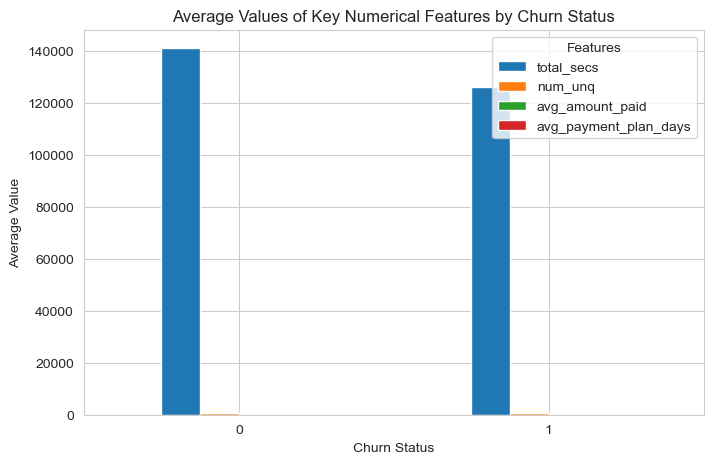

In [78]:
# 5 Compare average values by churn
# Compare the mean of important numerical variables by churn
churn_means = df.groupby('is_churn')[[
    'total_secs', 'num_unq', 'avg_amount_paid', 'avg_payment_plan_days'
]].mean().round(2)
print("\nAverage values of key numerical features by churn status:")
print(churn_means)

# print percentage of average values by churn status
print("\nPercentage of average values by churn status:")
print((churn_means / churn_means.sum() * 100).round(2))

# Plot average values by churn status
churn_means.plot(kind='bar')
plt.title("Average Values of Key Numerical Features by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Features")
plt.show()


##### 2.3.3. Key Question 3: When does churn tend to occur?

In [ ]:
# 1 Convert date columns
# Convert date columns to datetime format

df["registration_init_time"] = pd.to_datetime(
   df["registration_init_time"].astype(str), format="%Y%m%d", errors="coerce"
)

df["membership_expire_date"] = pd.to_datetime(
   df["membership_expire_date"].astype(str), format="%Y%m%d", errors="coerce"
)

df["last_transaction_date"] = pd.to_datetime(df["last_transaction_date"], errors="coerce")
df["first_transaction_date"] = pd.to_datetime(
    df["first_transaction_date"], errors="coerce"
)
# Check conversion
print("\nMissing values after date conversion:")
print("registration_init_time:", df["registration_init_time"].isna().sum())
print("membership_expire_date:", df["membership_expire_date"].isna().sum())
print("last_transaction_date:", df["last_transaction_date"].isna().sum())
print("first_transaction_date:", df["first_transaction_date"].isna().sum())


Missing values after date conversion:
registration_init_time: 970960
membership_expire_date: 970960
last_transaction_date: 37382
first_transaction_date: 37382



Customer age in days created successfully. Sample values:
                                           msno registration_init_time  \
0  ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=                    NaT   
1  f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=                    NaT   
2  zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=                    NaT   
3  8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=                    NaT   
4  K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=                    NaT   

   customer_age_days  
0                NaN  
1                NaN  
2                NaN  
3                NaN  
4                NaN  


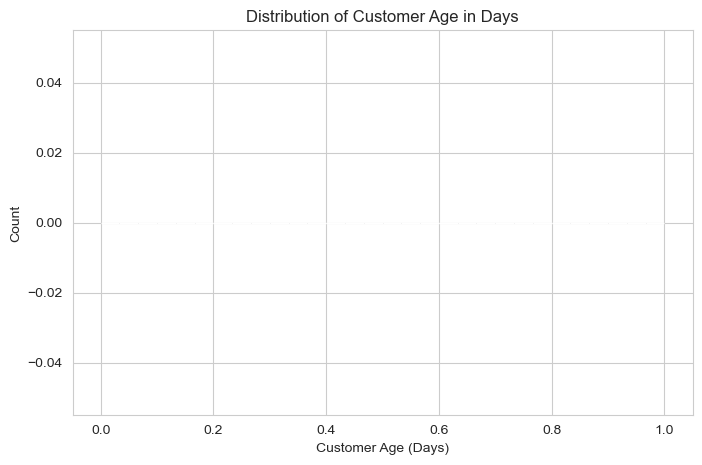

In [83]:
# 2 Customer age in days
# Create customer age in days

df["customer_age_days"] = (pd.to_datetime("2024-06-01") - df["registration_init_time"]).dt.days
print("\nCustomer age in days created successfully. Sample values:")
print(df[["msno", "registration_init_time", "customer_age_days"]].head())

# plot distribution of customer age in days
sns.histplot(df["customer_age_days"], bins=30, kde=True)
plt.title("Distribution of Customer Age in Days")
plt.xlabel("Customer Age (Days)")
plt.ylabel("Count")
plt.show()



Days until membership expiration created successfully. Sample values:
                                           msno membership_expire_date  \
0  ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=                    NaT   
1  f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=                    NaT   
2  zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=                    NaT   
3  8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=                    NaT   
4  K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=                    NaT   

   days_to_expiration  
0                 NaN  
1                 NaN  
2                 NaN  
3                 NaN  
4                 NaN  


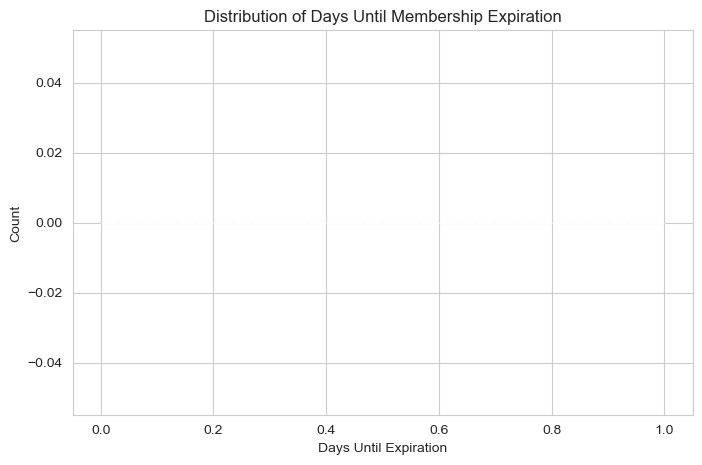

In [84]:
# 3. Days until membership expiration
# Create days to expiration

df["days_to_expiration"] = (df["membership_expire_date"] - pd.to_datetime("2024-06-01")).dt.days
print("\nDays until membership expiration created successfully. Sample values:")
print(df[["msno", "membership_expire_date", "days_to_expiration"]].head())

# plot distribution of days to expiration
sns.histplot(df["days_to_expiration"], bins=30, kde=True)
plt.title("Distribution of Days Until Membership Expiration")
plt.xlabel("Days Until Expiration")
plt.ylabel("Count")
plt.show()



Customer lifecycle groups created successfully. Sample values:
                                           msno  days_to_expiration  \
0  ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=                 NaN   
1  f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=                 NaN   
2  zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=                 NaN   
3  8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=                 NaN   
4  K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=                 NaN   

  lifecycle_group  
0         Unknown  
1         Unknown  
2         Unknown  
3         Unknown  
4         Unknown  

Churn rate by lifecycle group:
lifecycle_group
Unknown    0.089942
Name: is_churn, dtype: float64


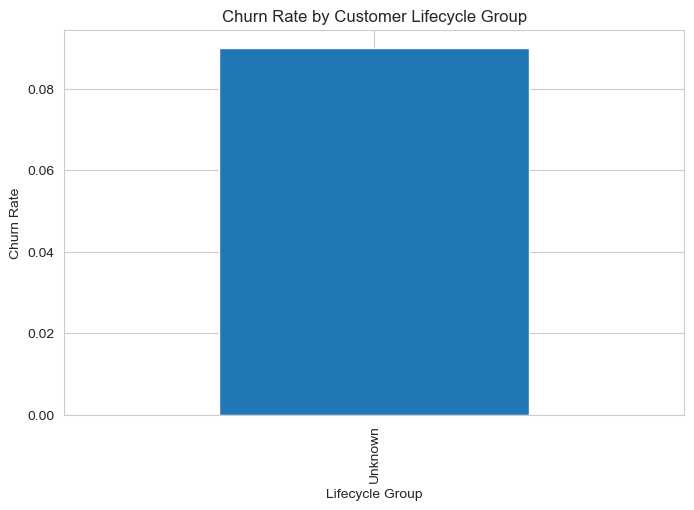


Percentage of churned customers by lifecycle group:
lifecycle_group
Unknown    8.99
Name: is_churn, dtype: float64


In [86]:
# 4. Churn by customer lifecycle group
# Create customer lifecycle groups

def lifecycle_group(days_to_expiration):
    if pd.isna(days_to_expiration):
        return "Unknown"
    elif days_to_expiration < 0:
        return "Expired"
    elif days_to_expiration <= 30:
        return "Expiring Soon"
    else:
        return "Active"
df["lifecycle_group"] = df["days_to_expiration"].apply(lifecycle_group)
print("\nCustomer lifecycle groups created successfully. Sample values:")
print(df[["msno", "days_to_expiration", "lifecycle_group"]].
head())

# plot churn rate by lifecycle group
churn_by_lifecycle = df.groupby("lifecycle_group")["is_churn"].mean()
print("\nChurn rate by lifecycle group:")
print(churn_by_lifecycle)
churn_by_lifecycle.plot(kind="bar")
plt.title("Churn Rate by Customer Lifecycle Group")
plt.xlabel("Lifecycle Group")
plt.ylabel("Churn Rate")
plt.show()

# print percentage of churned customers by lifecycle group
print("\nPercentage of churned customers by lifecycle group:")
print((churn_by_lifecycle * 100).round(2))


In [ ]:
# 3 Days until membership expiration
# Create days to expiration

df["days_to_expiration"] = (df["membership_expire_date"] - pd.to_datetime("2024-06-01")).dt.days
print("\nDays until membership expiration created successfully. Sample values:")
print(df[["msno", "membership_expire_date", "days_to_expiration"]].head())                  


Days until membership expiration created successfully. Sample values:
                                           msno membership_expire_date  \
0  ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=                    NaT   
1  f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=                    NaT   
2  zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=                    NaT   
3  8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=                    NaT   
4  K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=                    NaT   

   days_to_expiration  
0                 NaN  
1                 NaN  
2                 NaN  
3                 NaN  
4                 NaN  



Customer lifecycle groups created successfully. Sample values:
                                           msno  days_to_expiration  \
0  ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=                 NaN   
1  f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=                 NaN   
2  zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=                 NaN   
3  8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=                 NaN   
4  K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=                 NaN   

  lifecycle_group  
0         Unknown  
1         Unknown  
2         Unknown  
3         Unknown  
4         Unknown  

Churn rate by lifecycle group:
lifecycle_group
Unknown    0.089942
Name: is_churn, dtype: float64


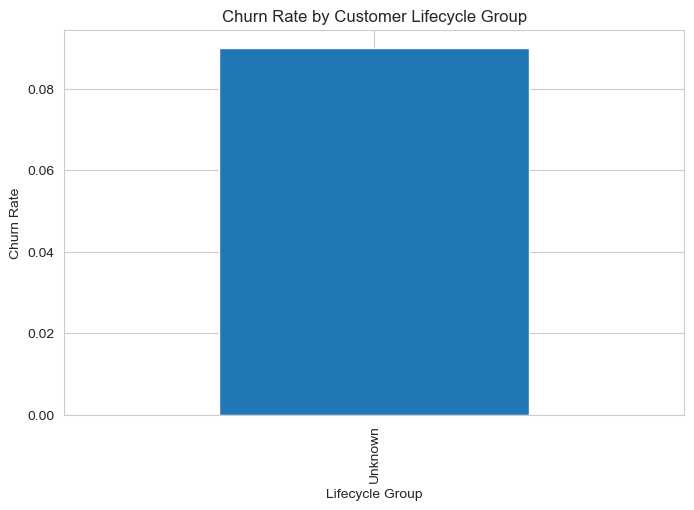


Percentage of churned customers by lifecycle group:
lifecycle_group
Unknown    8.99
Name: is_churn, dtype: float64


In [90]:
# 4. Churn by customer lifecycle group
# Create customer lifecycle groups

def lifecycle_group(days_to_expiration):
    if pd.isna(days_to_expiration):
        return "Unknown"
    elif days_to_expiration < 0:
        return "Expired"
    elif days_to_expiration <= 30:
        return "Expiring Soon"
    else:
        return "Active"
df["lifecycle_group"] = df["days_to_expiration"].apply(lifecycle_group)
print("\nCustomer lifecycle groups created successfully. Sample values:")
print(df[["msno", "days_to_expiration", "lifecycle_group"]].head())

# plot churn rate by lifecycle group
churn_by_lifecycle = df.groupby("lifecycle_group")["is_churn"].mean()
print("\nChurn rate by lifecycle group:")
print(churn_by_lifecycle)
churn_by_lifecycle.plot(kind="bar")
plt.title("Churn Rate by Customer Lifecycle Group")
plt.xlabel("Lifecycle Group")

plt.ylabel("Churn Rate")
plt.show()

# print percentage of churned customers by lifecycle group
print("\nPercentage of churned customers by lifecycle group:")
print((churn_by_lifecycle * 100).round(2))

##### 2.3.4. Key Question 4: Which variables appear most strongly related to churn?

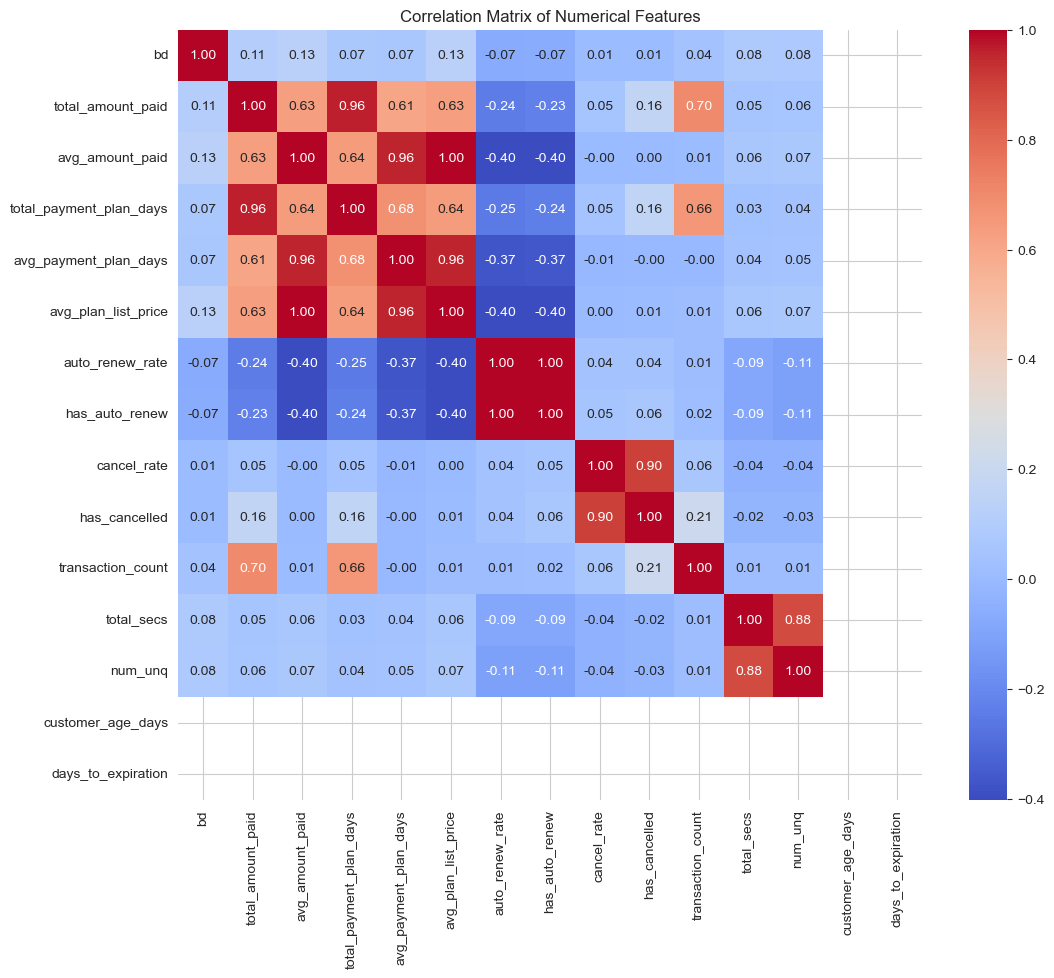

In [91]:
# 1 Correlation matrix
# Select numerical columns for correlation

numerical_cols = [
    'bd', 'total_amount_paid', 'avg_amount_paid', 'total_payment_plan_days',
    'avg_payment_plan_days', 'avg_plan_list_price', 'auto_renew_rate',
    'has_auto_renew', 'cancel_rate', 'has_cancelled', 'transaction_count',
    'total_secs', 'num_unq', 'customer_age_days', 'days_to_expiration'
]
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [94]:
# Select numerical columns including the target
num_cols = [
    "is_churn",
    "total_amount_paid",
    "avg_amount_paid",
    "total_payment_plan_days",
    "avg_payment_plan_days",
    "avg_plan_list_price",
    "auto_renew_rate",
    "has_auto_renew",
    "cancel_rate",
    "has_cancelled",
    "transaction_count"
]

# Keep only columns that actually exist in df
num_cols = [col for col in num_cols if col in df.columns]

# Create correlation matrix
correlation_matrix = df[num_cols].corr()

print(correlation_matrix)


                         is_churn  total_amount_paid  avg_amount_paid  \
is_churn                 1.000000           0.389932         0.429304   
total_amount_paid        0.389932           1.000000         0.632173   
avg_amount_paid          0.429304           0.632173         1.000000   
total_payment_plan_days  0.426189           0.962254         0.638758   
avg_payment_plan_days    0.448530           0.605866         0.958150   
avg_plan_list_price      0.433769           0.631233         0.998881   
auto_renew_rate         -0.313766          -0.243123        -0.401675   
has_auto_renew          -0.307020          -0.231501        -0.396731   
cancel_rate              0.462274           0.049157        -0.000561   
has_cancelled            0.424513           0.164901         0.002213   
transaction_count        0.149785           0.701978         0.008900   

                         total_payment_plan_days  avg_payment_plan_days  \
is_churn                                0.426189


Correlation of numerical features with churn:
cancel_rate                0.462274
avg_payment_plan_days      0.448530
avg_plan_list_price        0.433769
avg_amount_paid            0.429304
total_payment_plan_days    0.426189
has_cancelled              0.424513
total_amount_paid          0.389932
transaction_count          0.149785
has_auto_renew            -0.307020
auto_renew_rate           -0.313766
Name: is_churn, dtype: float64


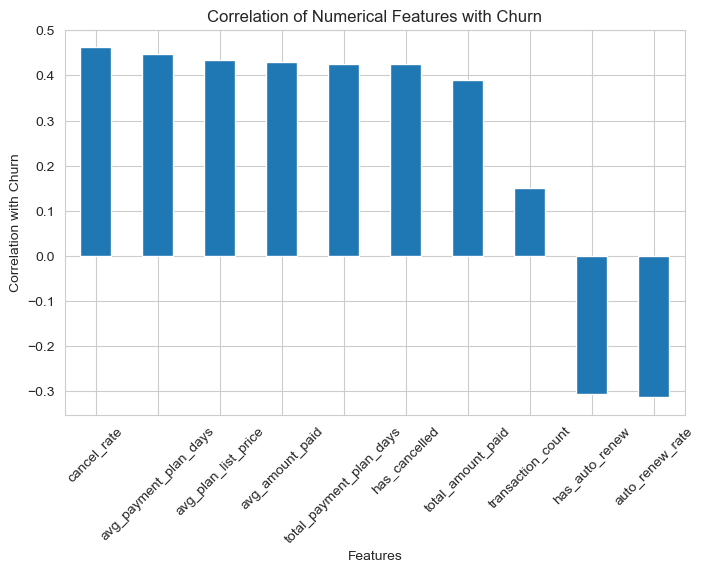

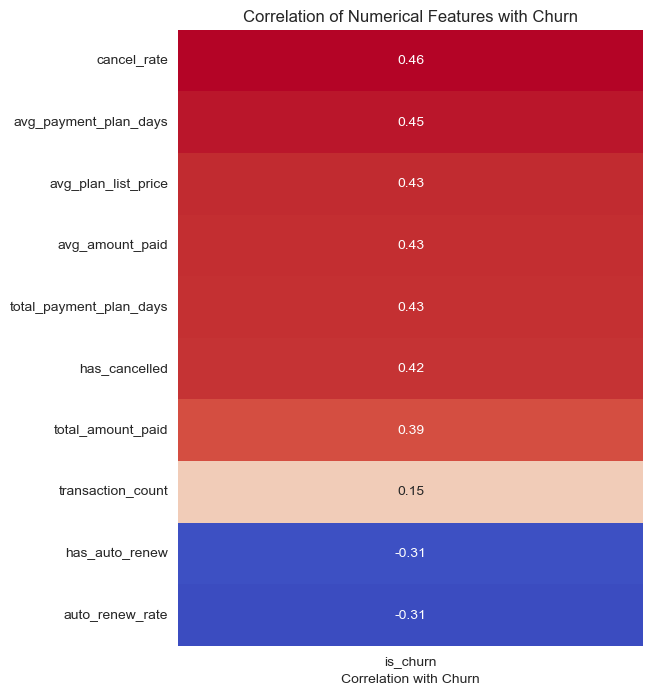


Percentage of correlation with churn:
cancel_rate                46.23
avg_payment_plan_days      44.85
avg_plan_list_price        43.38
avg_amount_paid            42.93
total_payment_plan_days    42.62
has_cancelled              42.45
total_amount_paid          38.99
transaction_count          14.98
has_auto_renew            -30.70
auto_renew_rate           -31.38
Name: is_churn, dtype: float64


In [101]:
# Correlation with churn
churn_correlation = correlation_matrix["is_churn"].drop("is_churn").sort_values(ascending=False)

print("\nCorrelation of numerical features with churn:")
print(churn_correlation)

# Plot correlation with churn
churn_correlation.plot(kind="bar")
plt.title("Correlation of Numerical Features with Churn")
plt.xlabel("Features")
plt.ylabel("Correlation with Churn")
plt.xticks(rotation=45)
plt.show()

# hitmap of correlation with churn 
plt.figure(figsize=(6, 8))
sns.heatmap(churn_correlation.to_frame(), annot=True, cmap="coolwarm", cbar=False)
plt.title("Correlation of Numerical Features with Churn")
plt.xlabel("Correlation with Churn")
plt.yticks(rotation=0)
plt.show()


# Print percentage of correlation with churn
print("\nPercentage of correlation with churn:")
print((churn_correlation * 100).round(2))

##### 2.3.5. Are there early signals that indicate churn risk?

listening_group
Low            10.986652
Medium-Low      8.620214
Medium-High     8.102864
High            8.147351
Name: is_churn, dtype: float64


C:\Users\pauli\AppData\Local\Temp\ipykernel_9572\277604227.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  listen_churn = df.groupby("listening_group")[target].mean() * 100


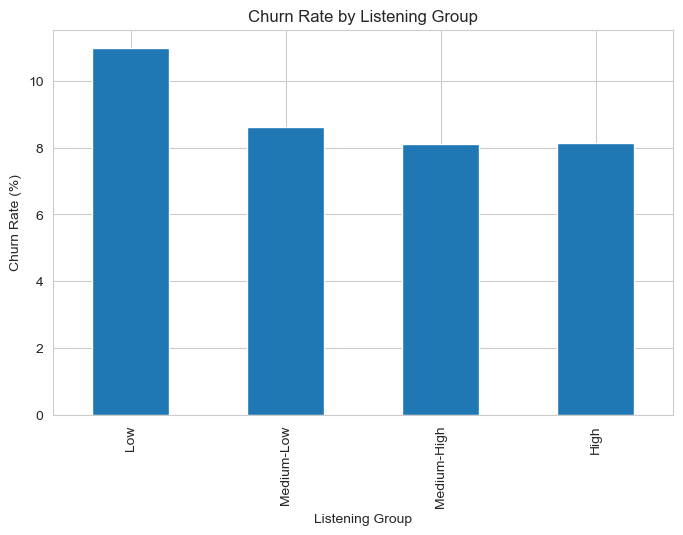

In [111]:
# 3 Low engagement as an early signal
# Create listening groups based on total listening time
df["listening_group"] = pd.qcut(df["total_secs"], q=4, labels=["Low", "Medium-Low", "Medium-High", "High"])
# Churn rate by listening group
listen_churn = df.groupby("listening_group")[target].mean() * 100
print(listen_churn)
# Plot churn by listening group
listen_churn.plot(kind="bar")
plt.title("Churn Rate by Listening Group")
plt.xlabel("Listening Group")
plt.ylabel("Churn Rate (%)")
plt.show()

In [ ]:
# Define target variable
target = "is_churn"

# Create a summary table for selected segments
risk_table = df.groupby(["has_auto_renew", "has_cancelled"])[target].agg(["mean", "count"]).reset_index()

# Convert churn rate to percentage r
risk_table["mean"] = risk_table["mean"] * 100

# Rename columns
risk_table = risk_table.rename(columns={
    "mean": "churn_rate_pct",
    "count": "customers"
})

print(risk_table)


   has_auto_renew  has_cancelled  churn_rate_pct  customers
0             0.0            0.0       30.261089      80777
1             1.0            0.0        1.702792     820476
2             1.0            1.0       60.262954      32325
